In [31]:
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets
from torchvision import transforms

from torchinfo import summary

from pathlib import Path

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [14]:
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"
train_dir = image_path / "train"
test_dir = image_path / "test"

In [15]:
normalize = transforms.Normalize(
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224, 0.225])

manual_transforms = transforms.Compose([
    normalize,
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [17]:
train_set = datasets.ImageFolder(root=train_dir, transform=manual_transforms)
test_set = datasets.ImageFolder(root=test_dir, transform=manual_transforms)

In [18]:
BATCH_SIZE = 32
NUM_WORKERS = 1

train_dataloader = DataLoader(train_set, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_set, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [19]:
class_names = train_set.classes
output_shape = len(class_names)
class_names

['pizza', 'steak', 'sushi']

In [21]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [22]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [23]:
train_set = datasets.ImageFolder(root=train_dir, transform=auto_transforms)
test_set = datasets.ImageFolder(root=test_dir, transform=auto_transforms)

In [24]:
train_dataloader = DataLoader(train_set, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_set, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [25]:
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\apost/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 10.7MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [28]:
summary(model=model, input_size=(32, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"], col_width=20, row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [29]:
for param in model.features.parameters():
    param.requires_grad = False
    
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=output_shape, bias=True)
).to(device)

In [30]:
summary(model=model, input_size=(32, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"], col_width=20, row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [36]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device):
    model.train()
    
    train_loss, train_acc, total_count = 0, 0, 0
    
    for batch, (X, y) in enumerate(dataloader):
        
        X, y = X.to(device), y.to(device)
        bs = X.size(0)
        
        y_logits = model(X)
        
        loss = loss_fn(y_logits, y)
        
        train_loss += loss.item() * bs
        train_acc += accuracy_fn(y_logits, y) * bs
        
        optimizer.zero_grad()
        
        loss.backward()
        
        optimizer.step()
        
        total_count += bs
    
    return train_loss / total_count, train_acc / total_count

In [37]:
def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module, 
              accuracy_fn,
              device):
    model.eval()
    
    test_loss, test_acc, total_count = 0, 0, 0
    
    with torch.inference_mode():
        
        for batch, (X, y) in enumerate(dataloader):
            
            X, y = X.to(device), y.to(device)
            bs = X.size(0)
            
            test_pred_logits = model(X)
            
            loss = loss_fn(test_pred_logits, y)
            
            test_loss += loss.item() * bs
            test_acc += accuracy_fn(test_pred_logits, y) * bs
            
            total_count += bs
        
    return test_loss / total_count, test_acc / total_count

In [38]:
from collections import defaultdict
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          accuracy_fn,
          epochs: int,
          device):
    
    results = defaultdict(list)
    
    for epoch in tqdm(range(1, epochs+1)):
        
        print(f"Epoch: {epoch}\n-------")
        
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, accuracy_fn, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, accuracy_fn, device)
        
        print(f"Train loss: {train_loss:.4f} | Train Accuracy: {train_acc:4f} | Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")
        
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
    
    return results

In [39]:
from torchmetrics import Accuracy

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
accuracy_fn = Accuracy("multiclass", num_classes=output_shape).to(device)

In [40]:
from timeit import default_timer as timer

start = timer()

results = train(model, train_dataloader, test_dataloader, optimizer, loss_fn, accuracy_fn, 5, device)

end = timer()

exe = end - start
print(f"Total time: {exe:.3f}s")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1
-------


 20%|██        | 1/5 [00:07<00:30,  7.60s/it]

Train loss: 1.0043 | Train Accuracy: 0.528889 | Test loss: 0.8165 | Test accuracy: 0.7733
Epoch: 2
-------


 40%|████      | 2/5 [00:14<00:21,  7.30s/it]

...

Train loss: 0.6725 | Train Accuracy: 0.857778 | Test loss: 0.6335 | Test accuracy: 0.8933
Epoch: 4
-------


 80%|████████  | 4/5 [00:28<00:07,  7.15s/it]

Train loss: 0.5794 | Train Accuracy: 0.915556 | Test loss: 0.5950 | Test accuracy: 0.9067
Epoch: 5
-------


100%|██████████| 5/5 [00:35<00:00,  7.19s/it]

Train loss: 0.5131 | Train Accuracy: 0.897778 | Test loss: 0.5766 | Test accuracy: 0.8533
Total time: 35.973s


In [42]:
import matplotlib.pyplot as plt

def plot_loss_curves(results):
    
    loss = results["train_loss"]
    test_loss = results["test_loss"]
    
    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]
    
    epochs = range(len(results["train_loss"]))
    
    plt.figure(figsize=(20, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

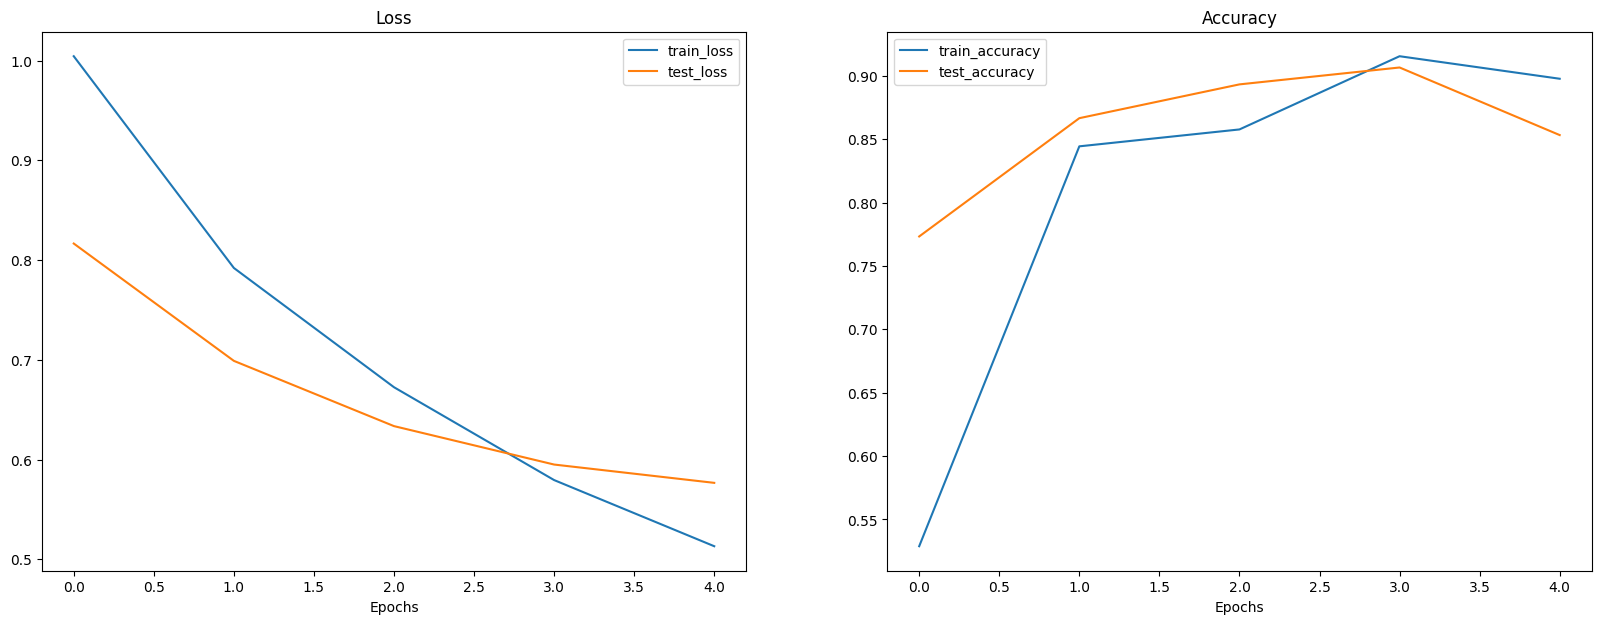

In [43]:
plot_loss_curves(results)